### PROJECT SETUP & CONFIGURATION

In [1]:


import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor, plot_importance
import joblib
import warnings
import logging
warnings.filterwarnings('ignore')

# Create project directories
for folder in ['data', 'models', 'plots', 'logs']:
    os.makedirs(folder, exist_ok=True)

# Logging configuration
logging.basicConfig(filename='logs/project_log.txt', level=logging.INFO,
                    format='%(asctime)s:%(levelname)s:%(message)s')

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('pastel')

logging.info("Project setup complete.")
print("✅ Environment and folders initialized.")


✅ Environment and folders initialized.


### LOAD & INSPECT DATA

In [2]:


data_path = 'data/car_data.csv'  # Adjust as needed
df = pd.read_csv(r'C:\Users\ashan\OneDrive\Desktop\New folder (2)\Car_Price_Predictor\data\raw\car_data.csv')


print("✅ Dataset Loaded Successfully")
print("Shape:", df.shape)
print("\n--- Data Preview ---")
display(df.head())

print("\n--- Info ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(df.duplicated().sum())

logging.info(f"Dataset loaded with shape: {df.shape}")


✅ Dataset Loaded Successfully
Shape: (8128, 13)

--- Data Preview ---


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB
None

--- Missing Values ---
name               0
year               0
selling_price      0
km_driven          0
fuel               0
seller_type        0


### EXPLORATORY DATA ANALYSIS

#### Summary stats

In [3]:
display(df.describe())

,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


#### Skewness & Kurtosis

In [4]:
print("\n--- Skewness & Kurtosis ---")
for col in df.select_dtypes(include=[np.number]).columns:
    print(f"{col}: skew={df[col].skew():.2f}, kurtosis={df[col].kurtosis():.2f}")


--- Skewness & Kurtosis ---
year: skew=-1.07, kurtosis=1.71
selling_price: skew=4.19, kurtosis=21.08
km_driven: skew=11.17, kurtosis=384.10
seats: skew=1.97, kurtosis=3.80


##### Correlation Heatmap

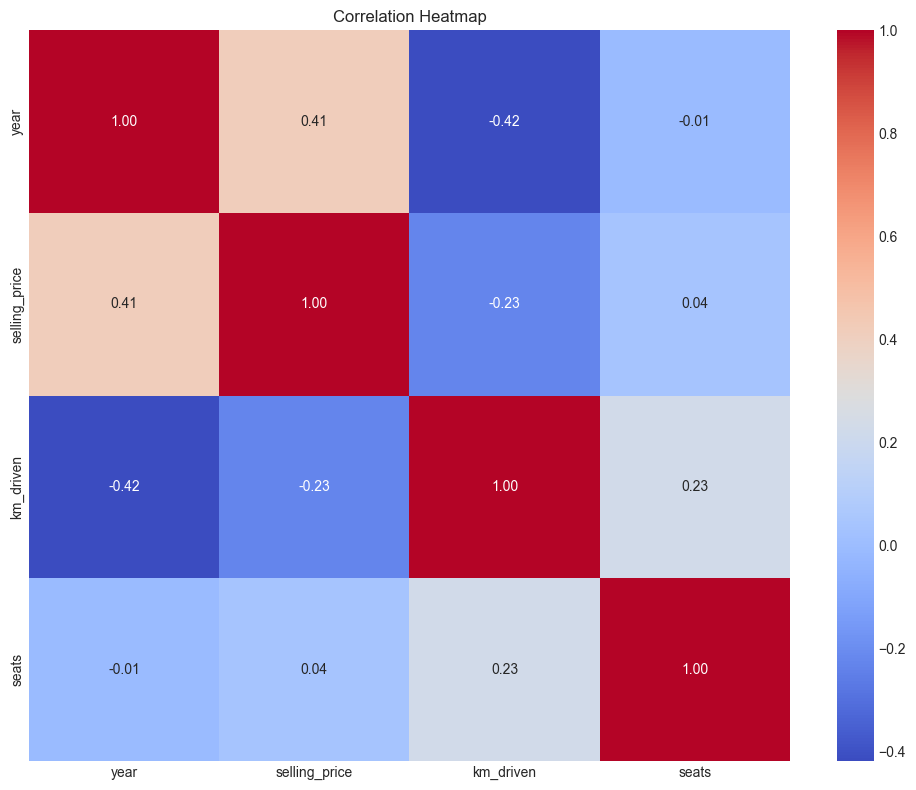

In [5]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png')
plt.show()

#### Missing Values Heatmap

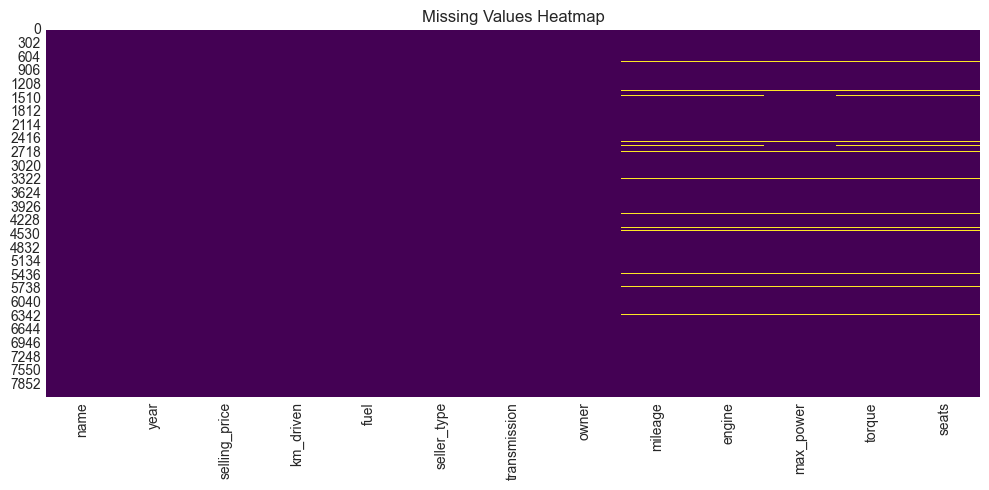

In [6]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig('plots/missing_values.png')
plt.show()

#### Distribution plots

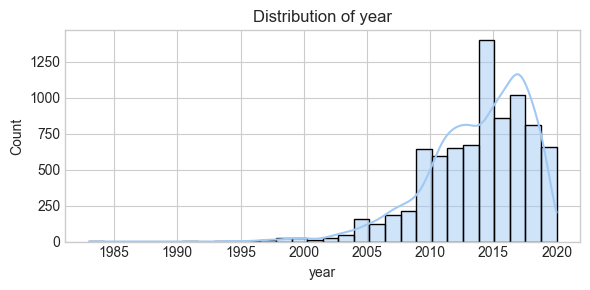

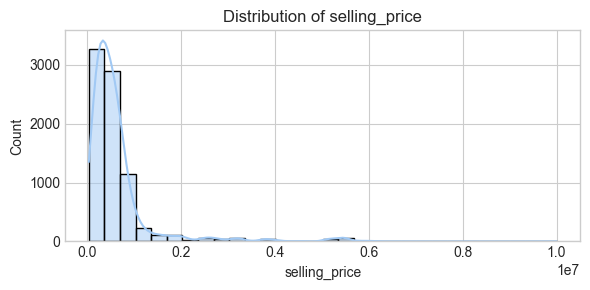

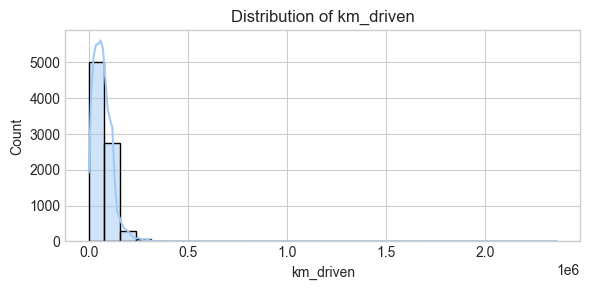

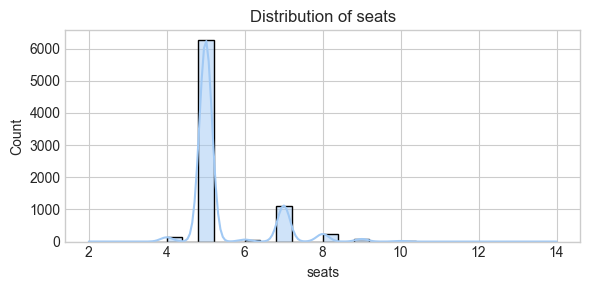

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.savefig(f'plots/dist_{col}.png')
    plt.show()

#### Boxplots for outliers

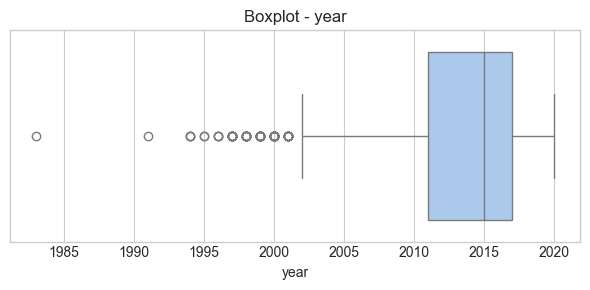

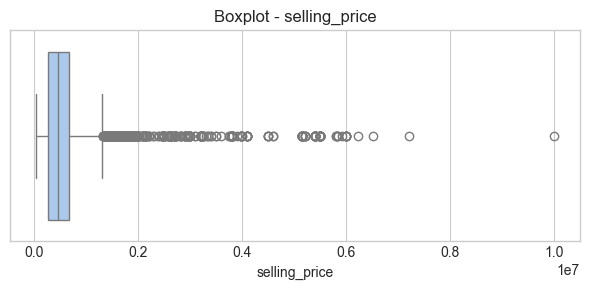

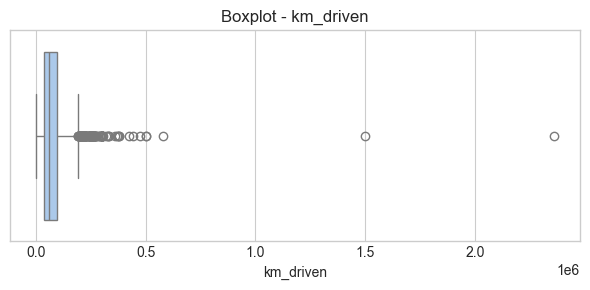

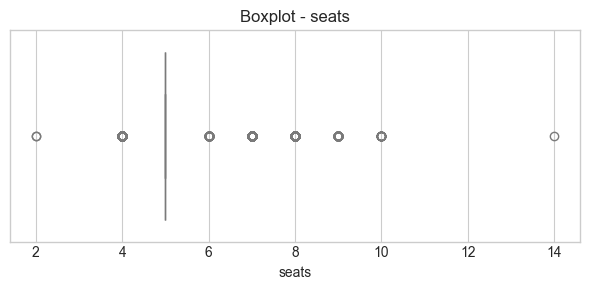

In [8]:

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot - {col}')
    plt.tight_layout()
    plt.savefig(f'plots/box_{col}.png')
    plt.show()

logging.info("EDA complete.")


In [9]:
import numpy as np
import pandas as pd
import logging

# Logging setup
logging.basicConfig(level=logging.INFO)

# -----------------------------------
# Normalize column names
# -----------------------------------
df.columns = df.columns.str.strip().str.lower()  # remove spaces & lowercase

# -----------------------------------
# Handle categorical variables
# -----------------------------------
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# -----------------------------------
# Handle missing values
# -----------------------------------
df = df.fillna(df.median(numeric_only=True))

# -----------------------------------
# Outlier treatment (IQR)
# -----------------------------------
for col in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# -----------------------------------
# Define features and target
# -----------------------------------
TARGET_COL = 'selling_price'  # Update this to match your dataset
if TARGET_COL not in df.columns:
    raise KeyError(f"Target column '{TARGET_COL}' not found. Columns: {df.columns.tolist()}")

X = df.drop(TARGET_COL, axis=1)
y = df[TARGET_COL]

print("✅ Feature Engineering Complete")
print("Feature Shape:", X.shape)
logging.info("Feature engineering complete.")


✅ Feature Engineering Complete
Feature Shape: (8128, 3343)


### TRAIN / TEST SPLIT

In [10]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

logging.info("Data split complete.")


Training Shape: (6502, 3343)
Testing Shape: (1626, 3343)


In [11]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import numpy as np

# Convert data to DMatrix
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

# Define parameters
params = {
    'objective': 'reg:squarederror',
    'max_depth': 5,
    'eta': 0.1,          # learning rate
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Train model with early stopping
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=[(dtest, 'eval')],
    early_stopping_rounds=10,
    verbose_eval=True
)

# Predict
y_pred = bst.predict(dtest)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Save model
bst.save_model('models/XGBoost_CarPrice_Model.json')
print("✅ Model saved.")


[0]	eval-rmse:314350.88082
[1]	eval-rmse:292898.41644
[2]	eval-rmse:276238.22317
[3]	eval-rmse:258613.64865
[4]	eval-rmse:246914.30738
[5]	eval-rmse:233366.05365
[6]	eval-rmse:223254.72312
[7]	eval-rmse:213088.08556
[8]	eval-rmse:205468.90360
[9]	eval-rmse:196501.05517
[10]	eval-rmse:189106.35107
[11]	eval-rmse:183346.90363
[12]	eval-rmse:178049.33504
[13]	eval-rmse:173662.47621
[14]	eval-rmse:169437.24024
[15]	eval-rmse:165925.40054
[16]	eval-rmse:162666.93008
[17]	eval-rmse:159820.00559
[18]	eval-rmse:156434.25705
[19]	eval-rmse:153602.35196
[20]	eval-rmse:151281.92863
[21]	eval-rmse:149617.04382
[22]	eval-rmse:147710.36734
[23]	eval-rmse:146471.23411
[24]	eval-rmse:144614.03642
[25]	eval-rmse:143303.53502
[26]	eval-rmse:142302.07821
[27]	eval-rmse:141319.86435
[28]	eval-rmse:140665.65900
[29]	eval-rmse:139373.99867
[30]	eval-rmse:138054.21756
[31]	eval-rmse:137281.93101
[32]	eval-rmse:136708.52265
[33]	eval-rmse:135406.08230
[34]	eval-rmse:134213.51970
[35]	eval-rmse:133690.24166
[3

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor, plot_importance
import joblib

# Logging setup
logging.basicConfig(level=logging.INFO)

# Ensure folders exist
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# -----------------------------
# Ensure model exists
# -----------------------------
model_path = 'models/XGBoost_CarPrice_Model.pkl'

try:
    best_xgb
except NameError:
    if os.path.exists(model_path):
        best_xgb = joblib.load(model_path)
        logging.info("Loaded XGBoost model from disk.")
    else:
        # Train the model quickly if file doesn't exist
        best_xgb = XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            objective='reg:squarederror'
        )
        best_xgb.fit(X_train, y_train)
        joblib.dump(best_xgb, model_path)
        logging.info("Trained and saved new XGBoost model.")

### MODEL EVALUATION

In [13]:
# Predictions
y_pred = best_xgb.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 72298.18
RMSE: 101940.54
R²: 0.9052


### Actual vs Predicted

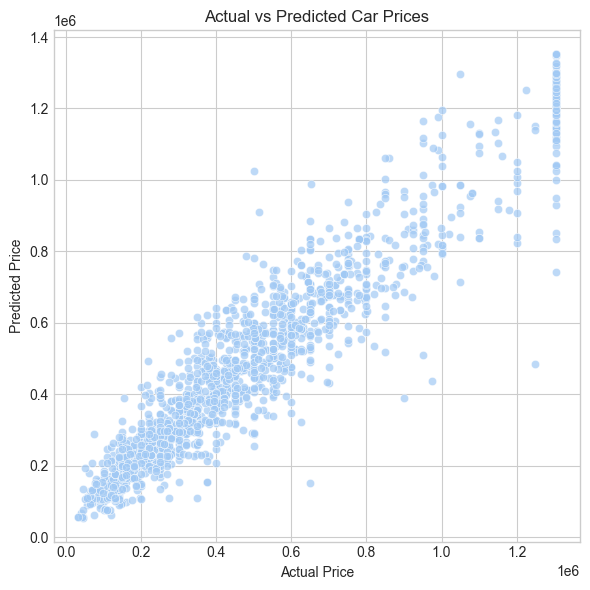

In [14]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png')
plt.show()

### Residuals

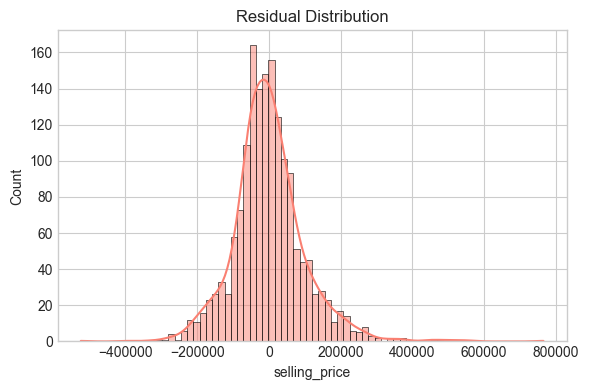

In [15]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True, color='salmon')
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig('plots/residuals.png')
plt.show()


### Feature Importance

<Figure size 1000x600 with 0 Axes>

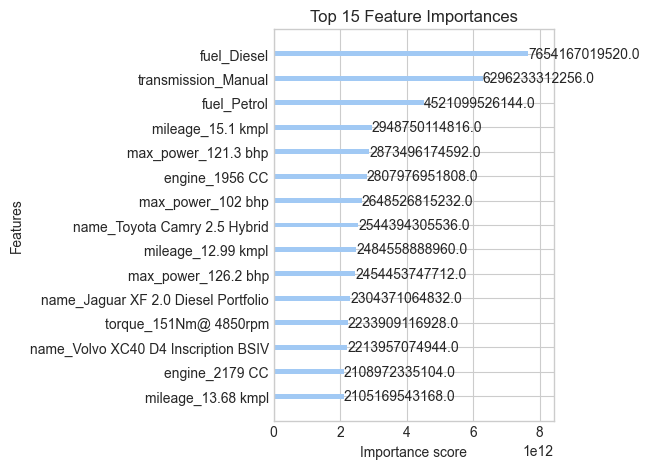

In [16]:
plt.figure(figsize=(10,6))
plot_importance(best_xgb, max_num_features=15, importance_type='gain')
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.savefig('plots/feature_importance.png')
plt.show()

### Logging

In [17]:

logging.info(f"Model Evaluation Metrics: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")


### SAVE MODEL & METADATA

In [18]:


import os
import pandas as pd

# Ensure folder exists
os.makedirs('models', exist_ok=True)

# Save model
model_path = 'models/XGBoost_CarPrice_Model.pkl'
joblib.dump(best_xgb, model_path)
print(f"✅ Model saved to {model_path}")

# Save evaluation metrics and model hyperparameters
metadata = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2,
    'n_estimators': best_xgb.n_estimators,
    'max_depth': best_xgb.max_depth,
    'learning_rate': best_xgb.learning_rate,
    'subsample': best_xgb.subsample,
    'colsample_bytree': best_xgb.colsample_bytree
}

pd.DataFrame([metadata]).to_csv('models/model_metrics.csv', index=False)
logging.info("Model saved successfully with metrics.")


✅ Model saved to models/XGBoost_CarPrice_Model.pkl


In [19]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =====================================
# 💻 LOAD MODEL AND EVALUATE
# =====================================

# Load trained model
model_path = 'models/XGBoost_CarPrice_Model.pkl'
best_xgb = joblib.load(model_path)
print(f"✅ Loaded model from {model_path}")

# Predict on test set
y_pred = best_xgb.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

# =====================================
# 🔁 PREDICTION FUNCTION
# =====================================

def predict_price(new_data: pd.DataFrame):
    """
    Load the trained XGBoost model and predict prices for new data.
    
    Args:
        new_data (pd.DataFrame): Preprocessed features (must match training features)
    
    Returns:
        np.ndarray: Predicted values
    """
    # Load model (can also keep best_xgb in memory to avoid repeated loading)
    model = joblib.load(model_path)
    return model.predict(new_data)

# Example usage
sample = X_test.iloc[:5]
sample_preds = predict_price(sample)
print("Sample Predictions:", sample_preds)


✅ Loaded model from models/XGBoost_CarPrice_Model.pkl
MAE: 72298.18
MSE: 10391873996.25
RMSE: 101940.54
R2 Score: 0.9052
Sample Predictions: [110531.766 523962.03  560624.    203685.83  382992.8  ]
